# Importations & configurations

In [1]:
# Istallation optuna pour l'optimisation bayésienne
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.3 MB/s eta 0:00:00


In [2]:
# Activation GPU pour Scikit-learn
%load_ext cuml.accel

In [3]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import json
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import getpass
import shutil
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
import time
import matplotlib.pyplot as plt
import random
random.seed(42)
np.random.seed(42)

# Chargement & Exploration

**Téléchargement**

In [4]:
# 1. Authentification sécurisée
os.environ['KAGGLE_USERNAME'] = input("Entrez votre nom d'utilisateur Kaggle : ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Collez votre clé secrète Kaggle : ")
# Authentification via l'API Kaggle en Python
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

# 2. Configuration du téléchargement et extraction
dataset = "abdallahalidev/plantvillage-dataset"
print("\nDébut du téléchargement et de l'extraction du dataset Kaggle...")
api.dataset_download_files(dataset, path='./plantvillage_data', unzip=True)

# 3. Nettoyage immédiat du disque pour éviter le gaspillage
print("Nettoyage des dossiers inutiles...")
base_path = './plantvillage_data'
target_dir = os.path.join(base_path, "plantvillage dataset")
shutil.rmtree(os.path.join(target_dir, "grayscale"), ignore_errors=True)
shutil.rmtree(os.path.join(target_dir, "segmented"), ignore_errors=True)

print("Téléchargement, extraction et nettoyage terminés ! Seul le dossier 'color' a été conservé.")

print("Téléchargement et extraction terminés avec succès ! Prêt pour l'étape suivante.")

Entrez votre nom d'utilisateur Kaggle : ulrichsdjro
Collez votre clé secrète Kaggle : ··········

Début du téléchargement et de l'extraction du dataset Kaggle...
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
Nettoyage des dossiers inutiles...
Téléchargement, extraction et nettoyage terminés ! Seul le dossier 'color' a été conservé.
Téléchargement et extraction terminés avec succès ! Prêt pour l'étape suivante.


**Chargement**

In [5]:
data_dir = '/content/plantvillage_data/plantvillage dataset/color'

# Charger les fichiers d'images de manière brute
# load_files associe automatiquement chaque sous-dossier à une étiquette de classe
data_raw = load_files(container_path=data_dir, load_content=False, shuffle=True, random_state=42)

# Récupération des chemins de fichiers et des labels numériques
X_filenames = data_raw.filenames
y_labels = data_raw.target
class_names = data_raw.target_names

print(f"\nNombre total d'images trouvées : {len(X_filenames)}")
print(f"Nombre de classes détectées : {len(class_names)}")
print(f"Exemples de classes : {class_names[:5]}")



Nombre total d'images trouvées : 54305
Nombre de classes détectées : 38
Exemples de classes : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


**Exploration**

Chemin de l'image d'exemple : /content/plantvillage_data/plantvillage dataset/color/Corn_(maize)___healthy/24ff01e1-c073-45df-90d7-da86e8fcece7___R.S_HL 8262 copy 2.jpg
Dimensions de l'image (hauteur, largeur, canaux) : (256, 256, 3)
Type de données des pixels : uint8
Nombre de classes : 38
Exemples de noms de classes : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy'] et ['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


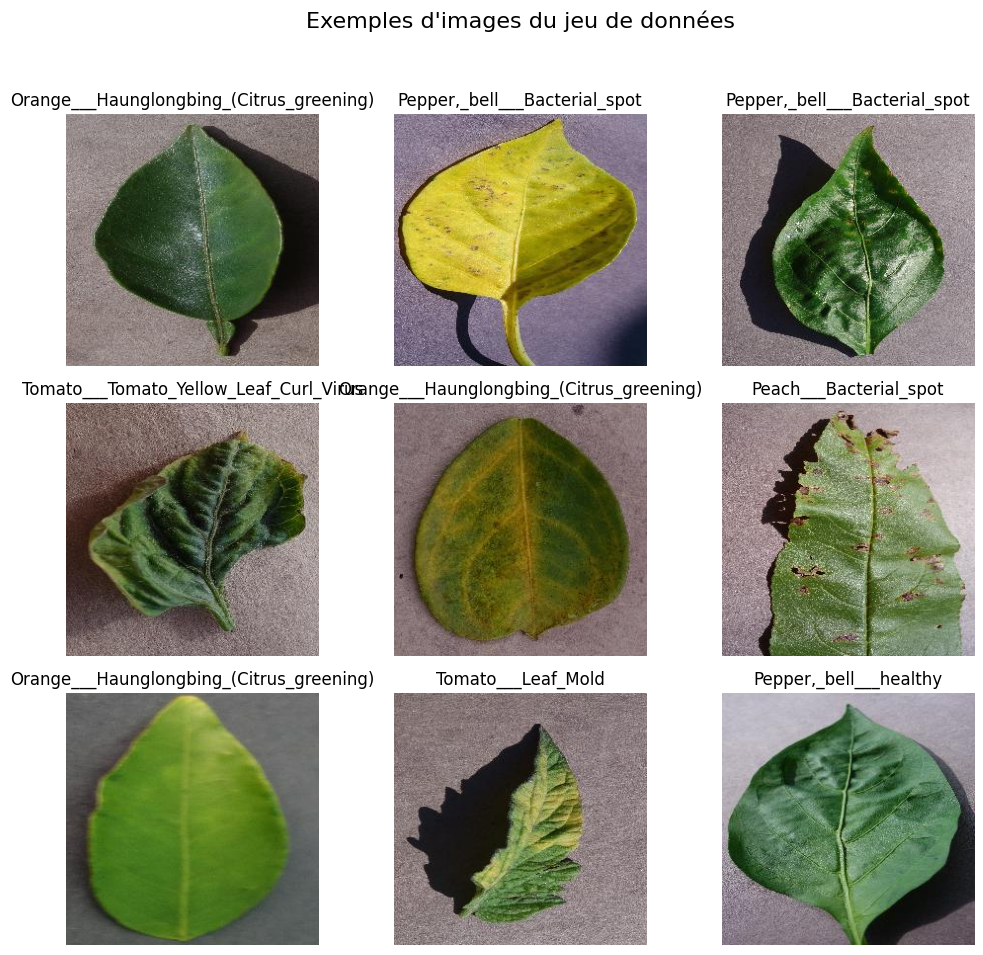

In [6]:
# prendre le chemin d'une image du dataset
example_image_path = X_filenames[0]

# lire l'image
example_img = cv2.imread(example_image_path)

# vérifier si l'image est bien chargée
if example_img is not None:
    print(f"Chemin de l'image d'exemple : {example_image_path}")
    print(f"Dimensions de l'image (hauteur, largeur, canaux) : {example_img.shape}")
    print(f"Type de données des pixels : {example_img.dtype}")
    print(f"Nombre de classes : {len(class_names)}")
    print(f"Exemples de noms de classes : {class_names[:5]} et {class_names[-5:]}")

    # Affichage aléatoire de certaines images
    plt.figure(figsize=(10, 10))
    plt.suptitle("Exemples d'images du jeu de données", fontsize=16)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        rand_idx = random.randint(0, len(X_filenames) - 1)
        img_path = X_filenames[rand_idx]
        img = cv2.imread(img_path)
        if img is not None:
            # OpenCV reads images in BGR, matplotlib expects RGB
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(class_names[y_labels[rand_idx]]) # Utilise y_labels pour les étiquettes
            plt.axis("off")
        else:
            print(f"Impossible de charger l'image : {img_path}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Impossible de charger l'image d'exemple : {example_image_path}")

# Train | Validation | Test

In [7]:


# Premier split : On isole 20% pour le Test final
X_train_val_files, X_test_files, y_train_val, y_test = train_test_split(
    X_filenames, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)

# 2. Deuxième split : Sur les 80% restants, on prend 12.5% pour la Validation
# (12.5% de 80% équivaut exactement à 10% du dataset total initial)
X_train_files, X_val_files, y_train, y_val = train_test_split(
    X_train_val_files, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(f"Images pour l'Entraînement (Train)   : {len(X_train_files)}")
print(f"Images pour l'Optimisation (Val)     : {len(X_val_files)}")
print(f"Images pour l'Évaluation finale (Test) : {len(X_test_files)}")

Images pour l'Entraînement (Train)   : 38013
Images pour l'Optimisation (Val)     : 5431
Images pour l'Évaluation finale (Test) : 10861


# Algorithme 1 - XGBOOST

Pour notre premier modèle de Machine Learning, nous avons sélectionné l'algorithme **XGBoost (eXtreme Gradient Boosting)** pour répondre aux exigences de performance, d'efficacité et d'explicabilité imposées par le cahier des charges du TP :

*   **Haute performance sur données tabulaires :** Bien que nous traitions des images, l'extraction préalable de caractéristiques globales transforme notre problème en un jeu de données tabulaires structurées. XGBoost est reconnu comme l'état de l'art mondial sur ce type de données grâce à son algorithme d'arbre de décision boosting.
*   **Explicabilité native (Explainable AI - XAI) :** Contrairement aux réseaux de neurones qui agissent souvent comme des "boîtes noires", XGBoost permet d'extraire de manière transparente l'**importance globale des caractéristiques (Feature Importance)**. Nous pourrons quantifier précisément l'impact de la couleur, de la texture ou de la géométrie de la feuille dans le diagnostic de la maladie.
*   **Optimisation et accélération matérielle :** Grâce à l'activation préalable de `%load_ext cuml.accel`, XGBoost exploite nativement l'infrastructure GPU (via la méthode `hist` et CUDA). Cela réduit drastiquement le temps nécessaire à la recherche d'hyperparamètres (GridSearch/RandomSearch) sur nos 54305 images, évitant ainsi la saturation de la mémoire vive (RAM) de Google Colab.

## Extraction des caractéristiques

Préparation des caractéristiques de la feuille (Couleur et Texture)

Pour aider le modèle XGBoost à prendre de bonnes décisions sans surcharger la mémoire de l'ordinateur, nous transformons chaque image de feuille en une liste de **160 indicateurs précis**.

Au lieu de donner les pixels bruts, nous découpons les informations en deux catégories :

* **A-) L'analyse des couleurs (128 indicateurs) :** Nous convertissons l'image dans un format (HSV) qui sépare la couleur de la lumière. Nous créons ensuite un graphique des couleurs de la feuille (Teinte, Saturation, Intensité). Cela permet de mesurer précisément la quantité de vert sain, de jaune (maladie) ou de marron (feuille brûlée ou morte).
* **B-) L'analyse des taches et des textures (32 indicateurs) :** Les maladies créent des taches, des trous ou des moisissures qui cassent l'aspect lisse de la feuille. Nous divisons la feuille en 16 petites zones (une grille de 4x4). Dans chaque zone, nous mesurons à quel point la surface est rugueuse ou change brutalement de couleur. Cela permet de savoir si les taches sont regroupées au même endroit ou dispersées partout.

**Pourquoi cette étape est essentielle pour la suite ?**
En transformant l'image en caractéristiques concrètes (le jaune, le marron, la rugosité locale), nous préparons le terrain pour l'étape d'explicabilité à la fin du TP. Quand le modèle aura terminé son apprentissage, nous pourrons lui demander exactement quelles couleurs ou quelles zones de taches ont dicté son diagnostic. C'est ce qui nous permettra de comprendre et d'expliquer ses décisions de manière logique et humaine.

In [8]:
def extract_high_performance_features(image_path):
    """
    Extrait des descripteurs riches (Histogrammes de couleurs et textures spatiales)
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Redimensionnement optimal (compromis RAM / Détails des maladies)
    img = cv2.resize(img, (128, 128))

    # 1. Histogramme de Couleur Riche (Espace HSV)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # 8 segments pour la Teinte, 4 pour la Saturation, 4 pour la Valeur = 128 caractéristiques
    hist_hsv = cv2.calcHist([hsv], [0, 1, 2], None, [8, 4, 4], [0, 180, 0, 255, 0, 255])
    hist_hsv = cv2.normalize(hist_hsv, hist_hsv).flatten()

    # 2. Descripteur de Texture spatial (Gradients Sobel distribués)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Réduction de la texture par sous-régions (Grille 4x4)
    # Calcule la rugosité locale dans 16 zones de la feuille
    texture_features = []
    h_step, w_step = 32, 32
    for i in range(4):
        for j in range(4):
            region = magnitude[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step]
            texture_features.append(np.mean(region))
            texture_features.append(np.std(region))

    # Combinaison des deux vecteurs (128 + 32 = 160 variables par image)
    return np.concatenate([hist_hsv, texture_features])

# Fonction globale sécurisée pour transformer les listes de chemins en matrices de caractéristiques
def process_enriched_dataset(file_paths, dataset_name="Dataset"):
    X_features = []
    for path in tqdm(file_paths, desc=f"Extraction {dataset_name}"):
        feats = extract_high_performance_features(path)
        if feats is not None:
            X_features.append(feats)
        else:
            # Sécurité : Vecteur de zéros si l'image ne peut pas être lue (128 + 32 = 160)
            X_features.append(np.zeros(160, dtype='float32'))
    return np.array(X_features, dtype='float32')

# --- Reconstruction des jeux de données tabulaires ---
print("--- Extraction des descripteurs enrichis (Visée Haute Performance) ---")
X_train_gb = process_enriched_dataset(X_train_files, "Train")
X_val_gb = process_enriched_dataset(X_val_files, "Validation")
X_test_gb = process_enriched_dataset(X_test_files, "Test")

print(f"\nNouvelles dimensions de la matrice Train : {X_train_gb.shape}")


--- Extraction des descripteurs enrichis (Visée Haute Performance) ---


Extraction Test: 100%|██████████| 10861/10861 [00:18<00:00, 588.89it/s]


Nouvelles dimensions de la matrice Train : (38013, 160)


## Recherche de la meilleure architecture

Nous utilisons l'optimisation bayésienne, implémentée avec la bibliothèque Optuna, pour trouver l'ensemble optimal d'hyperparamètres pour notre modèle. Cette approche est préférée aux recherches sur grille (Grid Search) ou aléatoires (Random Search) car elle est plus efficace, surtout dans les espaces de recherche de grande dimension. L'optimisation bayésienne construit un modèle probabiliste des performances des hyperparamètres et utilise ce modèle pour choisir intelligemment les prochains hyperparamètres à évaluer, réduisant ainsi le nombre d'essais nécessaires pour trouver une bonne solution.

**Fonction objective**

In [ ]:

# Variable globale pour suivre le nombre d'architectures réellement testées
trials_counter = 0

def objective_xgb(trial):
    global trials_counter

    # Espace de recherche (160 caractéristiques)
    params = {
        # --- Architecture des Arbres ---
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200, step=100),
        'max_depth': trial.suggest_int('max_depth', 6, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),

        # --- Comportement de l'Apprentissage ---
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),

        # --- Régularisation et Anti-Surapprentissage (Overfitting) ---
        # On resserre la sélection de variables à chaque arbre pour éviter le bruit
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-5, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-5, 5.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-5, 5.0, log=True),

        # --- Paramètres Fixes de Performance et Matériel ---
        'tree_method': 'hist',
        'device': 'cuda',       # Exploitation maximale du GPU de Colab
        'random_state': 42,
        'eval_metric': 'mlogloss'
    }

    # Initialisation de l'architecture spécifique à cet essai
    model = XGBClassifier(**params)

    # Entraînement sur la nouvelle matrice de taille (38013, 160)
    model.fit(X_train_gb, y_train)

    # Évaluation sur le lot Validation
    preds = model.predict(X_val_gb)
    score = accuracy_score(y_val, preds)

    return score


**Recherche et bilan de la recherche**

In [ ]:
# Compromis idéal entre temps de calcul et performance maximale
TOTAL_ARCHITECTURES_TO_TRY = 30

print(f"--- Début de la Recherche Bayésienne (Objectif : {TOTAL_ARCHITECTURES_TO_TRY} architectures) ---")

# Déclenchement du chronomètre
start_time_xgb = time.time()

# Création de l'étude Optuna
study_xgb = optuna.create_study(direction="maximize")

# Réinitialisation du compteur pour cette recherche
trials_counter = 0

# Barre de progression personnalisée pour suivre le nombre d'essais en temps réel
with tqdm(total=TOTAL_ARCHITECTURES_TO_TRY, desc="Architectures explorées") as pbar:
    def tqdm_callback(study, trial):
        global trials_counter
        trials_counter += 1
        pbar.update(1)
        pbar.set_postfix({
            "Essai_Actuel": f"{trials_counter}/{TOTAL_ARCHITECTURES_TO_TRY}",
            "Meilleur_Score": f"{study.best_value:.4f}"
        })

    # Lancement de l'optimisation parallélisée (n_jobs=-1)
    study_xgb.optimize(
        objective_xgb,
        n_trials=TOTAL_ARCHITECTURES_TO_TRY,
        n_jobs=-1,
        callbacks=[tqdm_callback]
    )

# Arrêt du chronomètre
end_time_xgb = time.time()
execution_time_xgb = end_time_xgb - start_time_xgb

print("\n--- Bilan de la recherche d'architecture XGBoost ---")
print(f"🎯 Nombre total d'architectures programmées : {TOTAL_ARCHITECTURES_TO_TRY}")
print(f"✅ Nombre total d'architectures essayées     : {trials_counter}")
print(f"⏱️ Temps total de recherche pour XGBoost   : {execution_time_xgb:.2f} secondes")
print(f"🏆 Meilleure précision de validation        : {study_xgb.best_value:.4f}")


--- Début de la Recherche Bayésienne (Objectif : 30 architectures) ---


Architectures explorées: 100%|██████████| 30/30 [41:12<00:00, 82.41s/it, Essai_Actuel=30/30, Meilleur_Score=0.9751]


--- Bilan de la recherche d'architecture XGBoost ---
🎯 Nombre total d'architectures programmées : 30
✅ Nombre total d'architectures essayées     : 30
⏱️ Temps total de recherche pour XGBoost   : 2472.41 secondes
🏆 Meilleure précision de validation        : 0.9751


**L'Architeture retenue**

In [ ]:
print("--- Architecture Gagnante Retenue pour XGBoost ---")

# 1. Extraction des meilleurs paramètres trouvés par Optuna
best_xgb_params = study_xgb.best_params

# 2. Sauvegarde automatique des paramètres matériels requis pour l'entraînement final futur
# (On fige la configuration GPU pour qu'elle soit prête à l'emploi)
best_xgb_params.update({
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'eval_metric': 'mlogloss'
})

# 3. Affichage
df_best_params = pd.DataFrame(
    [(k, v) for k, v in best_xgb_params.items() if k not in ['tree_method', 'device', 'random_state', 'eval_metric']],
    columns=['Hyperparamètre', 'Valeur Optimale']
)
display(df_best_params)


--- Architecture Gagnante Retenue pour XGBoost ---


,Hyperparamètre,Valeur Optimale
0,n_estimators,1200.000000
1,max_depth,7.000000
2,min_child_weight,2.000000
3,learning_rate,0.099498
4,subsample,0.700369
5,colsample_bytree,0.846162
6,gamma,0.004859
7,alpha,0.003462
8,lambda,3.064371


## Modélisation finale

In [10]:
# Ensure best_hyperparams is available
if 'best_hyperparams' not in locals():
    print("Error: Variable 'best_hyperparams' not found. Please ensure the cell for hyperparameter loading (e.g., 'jwQy9xJxgdmj') has been executed.")
    raise NameError("Missing required variable: best_hyperparams")

# Ensure processed data variables are available.
missing_processed_data_vars = []
for var_name in ['X_train_gb', 'y_train', 'X_val_gb', 'y_val', 'X_test_gb', 'y_test', 'class_names']:
    if var_name not in locals():
        missing_processed_data_vars.append(var_name)

if missing_processed_data_vars:
    print(f"Error: The following processed data variables are not defined: {', '.join(missing_processed_data_vars)}.")
    print("Please ensure the feature extraction cell (e.g., 'HTTu5OtRFD4k') has been executed before running this cell.")
    raise NameError(f"Missing required processed data variables: {', '.join(missing_processed_data_vars)}")

In [11]:
# Fusionner les ensembles d'entraînement et de validation pour l'entraînement final
X_train_final_gb = np.concatenate((X_train_gb, X_val_gb), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

print(f"Dimensions de l'ensemble d'entraînement final (train + val) : {X_train_final_gb.shape}")

Dimensions de l'ensemble d'entraînement final (train + val) : (43444, 160)


In [12]:
# 1. Instanciation du modèle XGBoost avec les meilleurs hyperparamètres chargés du fichier
# best_hyperparams contient les paramètres chargés du fichier JSON
final_xgb_model = XGBClassifier(**best_hyperparams)

# 2. Entraînement du modèle sur l'ensemble d'entraînement complet (training + validation)
print("Entraînement du modèle XGBoost final...")
final_xgb_model.fit(X_train_final_gb, y_train_final)
print("Modèle XGBoost final entraîné avec succès.")

Entraînement du modèle XGBoost final...
Modèle XGBoost final entraîné avec succès.



Évaluation du modèle sur l'ensemble de test...
Précision sur l'ensemble de test pour XGBoost: 0.9735

Rapport de classification XGBoost sur l'ensemble de test :
|                                                    | precision   | recall   | f1-score   | support   |
|:---------------------------------------------------|:------------|:---------|:-----------|:----------|
| Apple___Apple_scab                                 | 0.934426    | 0.904762 | 0.919355   | 126       |
| Apple___Black_rot                                  | 1           | 0.943548 | 0.970954   | 124       |
| Apple___Cedar_apple_rust                           | 0.979592    | 0.872727 | 0.923077   | 55        |
| Apple___healthy                                    | 0.966767    | 0.972644 | 0.969697   | 329       |
| Blueberry___healthy                                | 0.986577    | 0.98     | 0.983278   | 300       |
| Cherry_(including_sour)___Powdery_mildew           | 0.985577    | 0.97619  | 0.980861   | 210       

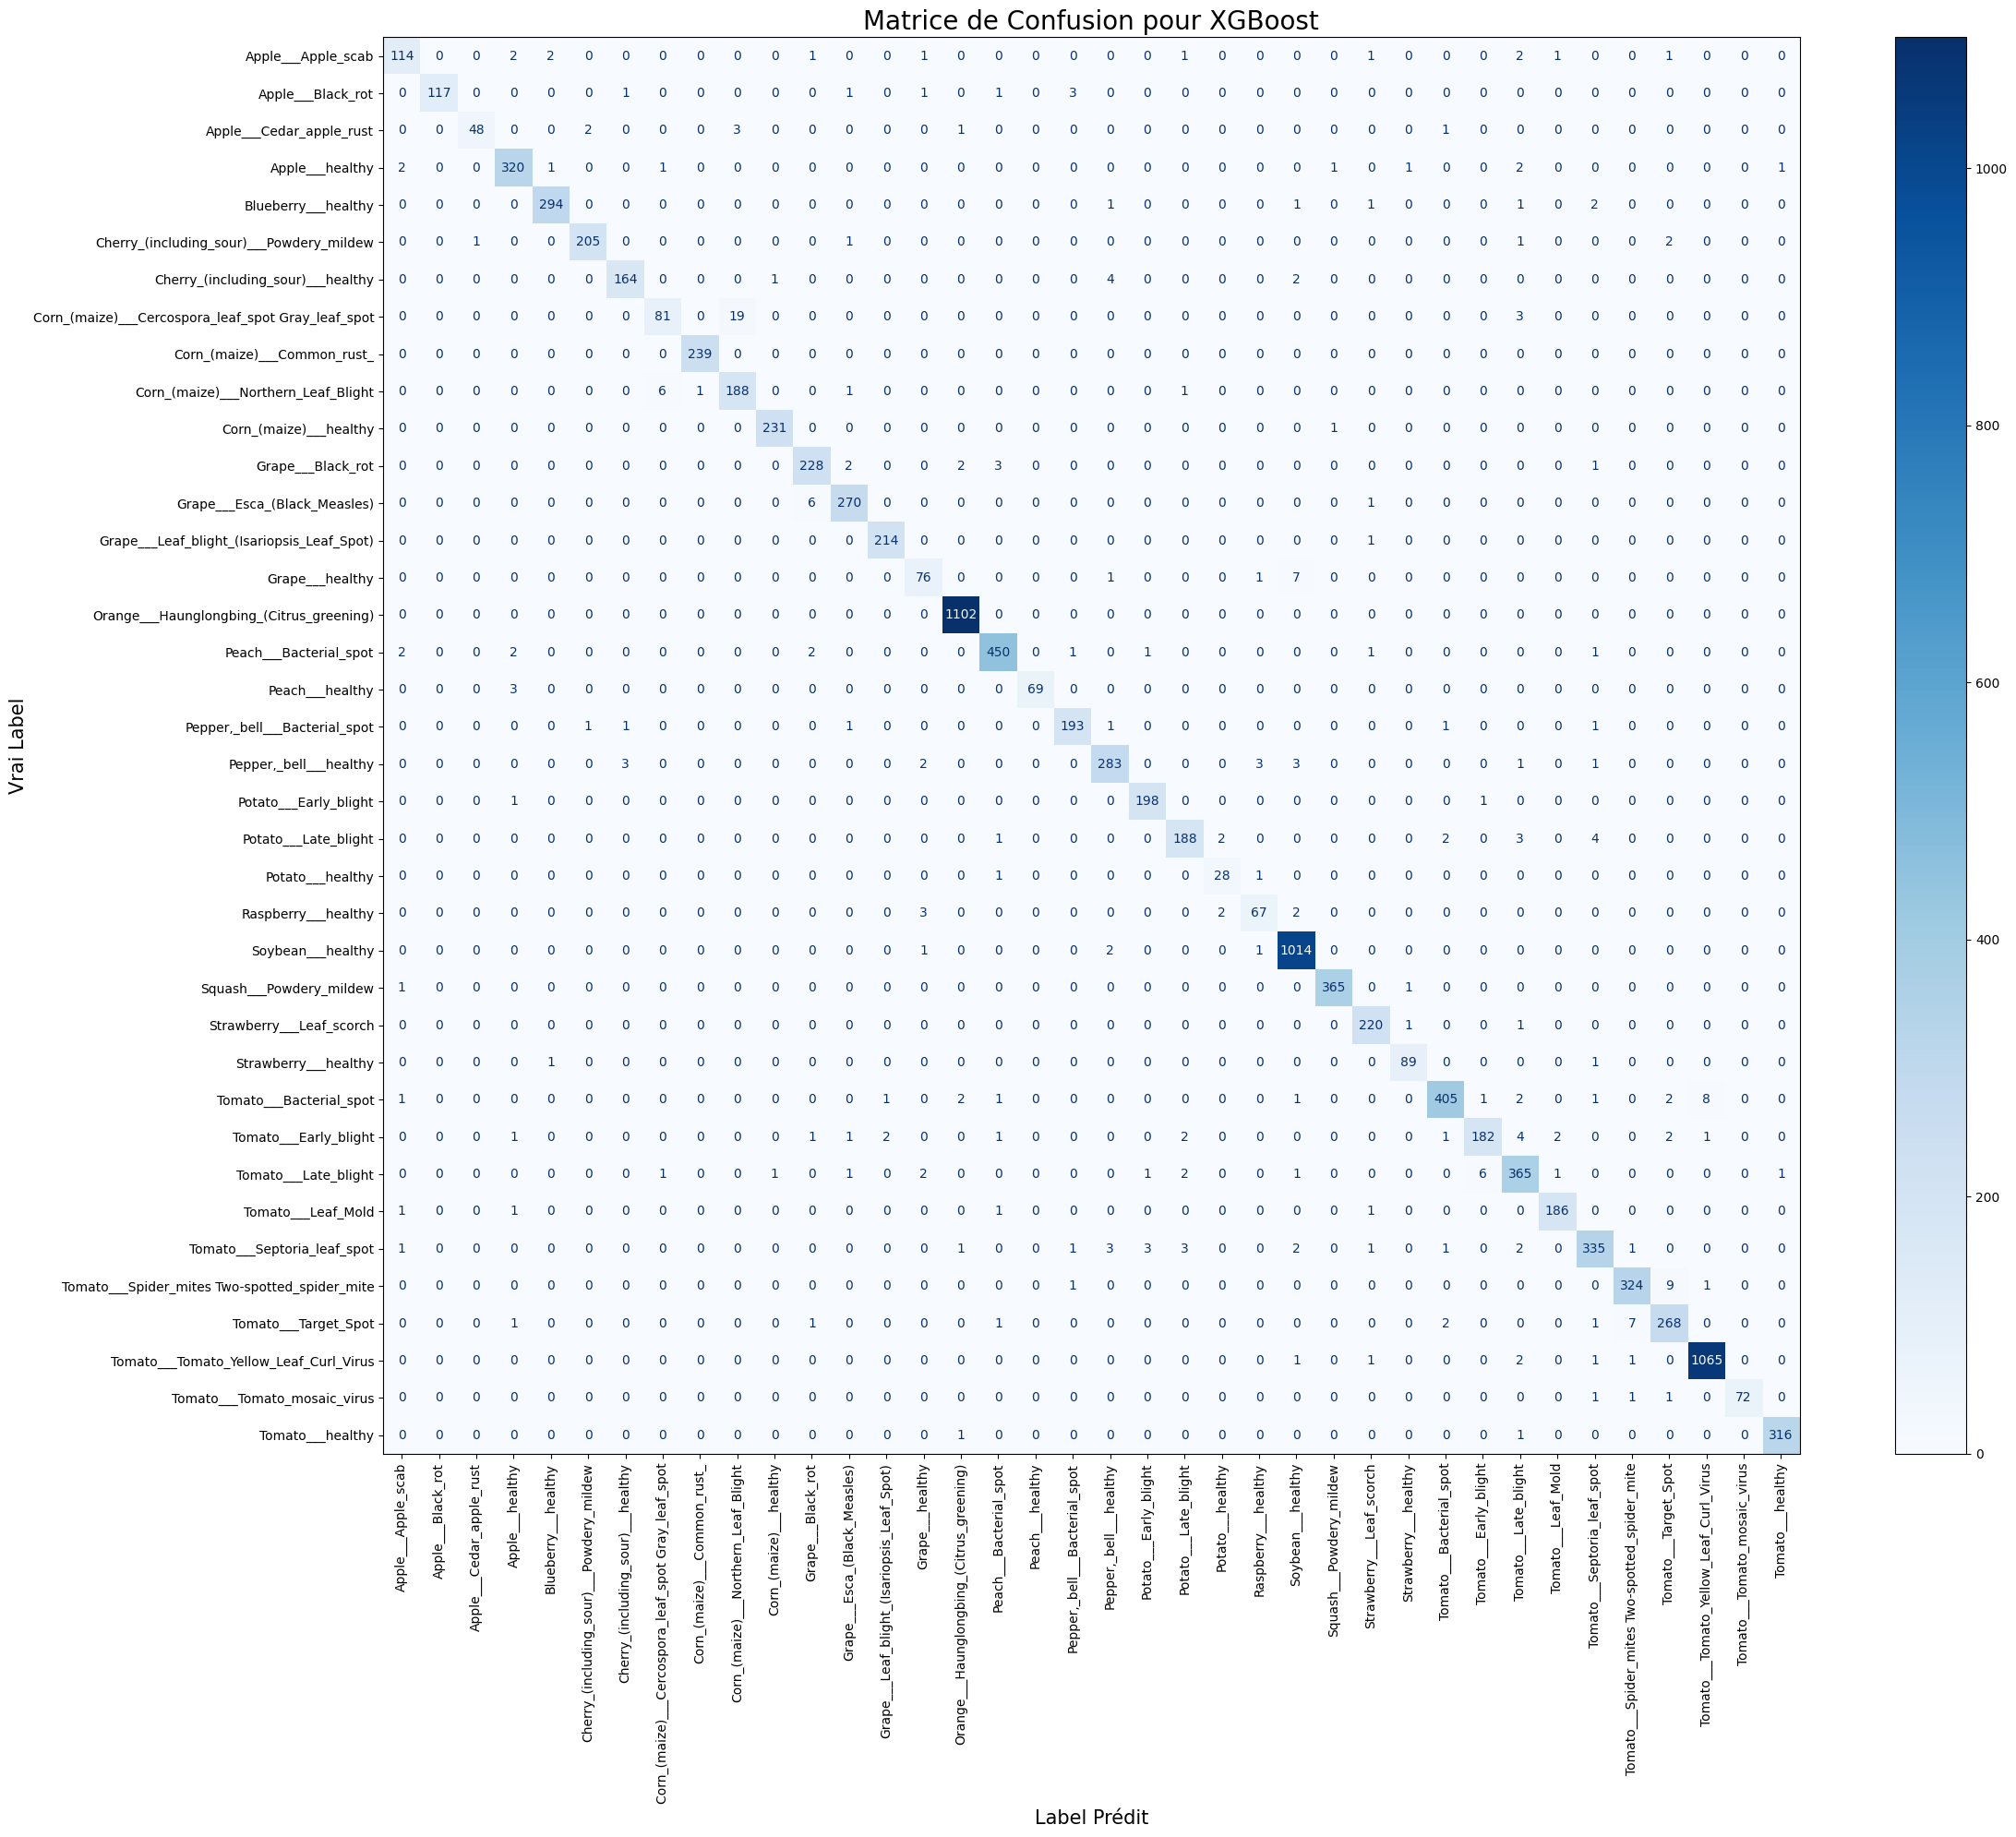

In [13]:
print("\nÉvaluation du modèle sur l'ensemble de test...")
y_pred_xgb = final_xgb_model.predict(X_test_gb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Précision sur l'ensemble de test pour XGBoost: {accuracy_xgb:.4f}")

# Classification Report
print("\nRapport de classification XGBoost sur l'ensemble de test :")
# Convert classification report to DataFrame for better display
report_xgb = classification_report(y_test, y_pred_xgb, target_names=class_names, zero_division=0, output_dict=True)
df_report_xgb = pd.DataFrame(report_xgb).transpose()
print(df_report_xgb.to_markdown(numalign="left", stralign="left")) # Utilise to_markdown pour un affichage propre dans Colab

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Adjust figure size for better readability with many classes, similar to CNN matrix
fig, ax = plt.subplots(figsize=(25, 20)) # Créer une figure et un ensemble d'axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d', ax=ax)
ax.set_title('Matrice de Confusion pour XGBoost', fontsize=20)
ax.set_xlabel('Label Prédit', fontsize=15)
ax.set_ylabel('Vrai Label', fontsize=15)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

In [15]:
print("\n--- Sauvegarde du modèle XGBoost entraîné ---")

# Définir le nom du fichier pour le modèle sauvegardé
final_xgb_model_path = 'final_xgb_model.json'

# Sauvegarder le modèle au format JSON (XGBoost supporte directement la sauvegarde en JSON)
final_xgb_model.save_model(final_xgb_model_path)

print(f"Modèle XGBoost final sauvegardé avec succès sous : {final_xgb_model_path}")


--- Sauvegarde du modèle XGBoost entraîné ---
Modèle XGBoost final sauvegardé avec succès sous : final_xgb_model.json


# Algorithme 2 - CNN

Pour notre second modèle, nous explorons les **Réseaux de Neurones Convolutionnels (CNN)**, une approche fondamentale et puissante pour l'analyse d'images. Contrairement à XGBoost qui s'appuie sur des *caractéristiques pré-extraites*, les CNN sont capables d'**apprendre automatiquement et hiérarchiquement des caractéristiques discriminantes directement à partir des pixels bruts**.

*   **Apprentissage profond des caractéristiques :** Les CNN excellent dans la détection de motifs visuels complexes (bords, textures, formes) à différentes échelles, ce qui est crucial pour identifier les symptômes subtils des maladies des plantes. Chaque couche du réseau apprend des représentations de plus en plus abstraites de l'image.
*   **Performance de pointe en vision par ordinateur :** Les CNN sont le standard de l'industrie pour la classification d'images et atteignent des performances inégalées sur des tâches visuelles complexes.
*   **Robustesse aux variations :** Grâce à des couches comme le *pooling*, les CNN peuvent devenir insensibles à de petites variations de position ou d'échelle des éléments dans l'image, rendant le modèle plus robuste.
*   **Complémentarité avec XGBoost :** En comparant les performances d'un modèle basé sur des caractéristiques artisanales (XGBoost) et un modèle apprenant ses propres caractéristiques (CNN), nous obtiendrons une vue plus complète des approches possibles et de leurs limites.

Pour construire un modèle CNN performant et robuste pour la classification des maladies des plantes, nous allons opter pour une approche de *Transfer Learning*. Cette méthode est largement plébiscitée en vision par ordinateur, notamment lorsque l'on dispose d'un dataset de taille moyenne, comme le nôtre.

**Stratégie adoptée:**

1.  **Modèle de base pré-entraîné (MobileNetV2):** Nous utiliserons `MobileNetV2` comme extracteur de caractéristiques. Ce modèle est réputé pour son efficacité computationnelle et sa capacité à capturer des caractéristiques visuelles complexes. Il a été pré-entraîné sur le vaste dataset ImageNet, ce qui lui confère une excellente capacité de généralisation.
    *   **Justification:** Le Transfer Learning permet de bénéficier de la connaissance acquise par un modèle sur une tâche similaire (classification d'objets généraux) et de l'appliquer à notre tâche spécifique (classification de maladies des plantes). Cela réduit considérablement le temps d'entraînement et la quantité de données nécessaires par rapport à l'entraînement d'un CNN from scratch. MobileNetV2 est un excellent compromis entre performance et légèreté, idéal pour des environnements comme Google Colab.

2.  **Gèle des couches du modèle de base:** Les couches du `MobileNetV2` seront initialement "gelées" (`trainable=False`). Cela signifie que leurs poids ne seront pas mis à jour pendant l'entraînement de nos nouvelles couches. L'idée est d'utiliser `MobileNetV2` comme un extracteur de caractéristiques fixe.
    *   **Justification:** Les premières couches des CNN pré-entraînés apprennent des caractéristiques génériques (bords, textures). Il n'est généralement pas nécessaire de les modifier pour une nouvelle tâche. Geler ces couches permet d'accélérer l'entraînement et de prévenir l'oubli catastrophique des caractéristiques apprises.

3.  **Ajout de couches de classification personnalisées:** Au-dessus du modèle de base, nous allons ajouter nos propres couches "tête" (pooling global, couches Dense, Batch Normalization, Dropout) pour adapter le modèle à nos 38 classes spécifiques.
    *   **Justification des hyperparamètres pour les couches personnalisées:**
        *   **`GlobalAveragePooling2D()`:** Réduit la dimensionnalité des caractéristiques du modèle de base avant les couches denses, réduisant ainsi le nombre de paramètres et le risque d'overfitting.
        *   **`Dense(512)`:** Une couche dense avec 512 neurones est un bon point de départ pour une tâche de classification de 38 classes, permettant au modèle d'apprendre des combinaisons plus complexes des caractéristiques extraites.
        *   **`BatchNormalization()`:** Normalise les activations des couches, ce qui stabilise l'entraînement et permet d'utiliser des taux d'apprentissage plus élevés. Elle agit également comme une forme de régularisation.
        *   **`Activation('relu')`:** La fonction d'activation ReLU est un choix standard et efficace pour les couches cachées des réseaux de neurones, offrant une bonne performance computationnelle.
        *   **`Dropout(0.4)`:** Une couche Dropout avec un taux de 0.4 (40% des neurones désactivés aléatoirement à chaque étape d'entraînement) est une technique de régularisation efficace pour prévenir le surapprentissage. Un taux de 0.4 est un bon compromis pour notre dataset.
        *   **`Dense(NUM_CLASSES, activation='softmax')`:** La couche de sortie doit avoir un nombre de neurones égal au nombre de classes (`NUM_CLASSES`, ici 38) et utiliser une activation `softmax` pour produire des probabilités de classe qui somment à 1.

4.  **Compilation du modèle:**
    *   **`Optimizer='Adam'`:** L'optimiseur Adam est un choix très populaire et robuste, combinant les avantages de RMSprop et AdaGrad. Il est connu pour sa convergence rapide et sa performance stable.
    *   **`Learning Rate=0.0001`:** Un taux d'apprentissage faible (0.0001) est souvent préféré en Transfer Learning, car on ne veut pas perturber trop brusquement les poids pré-entraînés du modèle de base, ni les couches nouvellement ajoutées.
    *   **`Loss='sparse_categorical_crossentropy'`:** Adapté à notre problème de classification multi-classes avec des labels encodés comme des entiers (comme `y_train`, `y_val`, etc.).
    *   **`Metrics=['accuracy']`:** L'exactitude est une métrique intuitive et facile à interpréter pour évaluer la performance de notre classifieur.

5.  **Entraînement avec `EarlyStopping`:**
    *   **`Epochs=10`:** Un nombre modéré d'époques pour un début. L'entraînement sera contrôlé par un `EarlyStopping`.
    *   **`EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)`:** Cette callback est cruciale. Elle arrêtera l'entraînement si la perte de validation ne s'améliore pas après 3 époques consécutives, empêchant le surapprentissage et économisant du temps de calcul. De plus, elle restaure les poids du modèle qui ont donné la meilleure performance sur l'ensemble de validation.

6. **Batch_size**

*   **`BATCH_SIZE = 32`:** Une taille de lot de 32 est un compromis courant. Elle est suffisamment grande pour fournir une estimation stable du gradient sans consommer trop de mémoire GPU, tout en étant suffisamment petite pour introduire du bruit dans l'entraînement, ce qui peut aider à la généralisation.

Cette configuration nous permettra d'obtenir un modèle performant et bien régularisé.

**Imports**

In [ ]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation,Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
import tensorflow as tf

**Prétraitement**

In [ ]:
# Paramètres pour le prétraitement (conservés ou redéfinis si nécessaire)
IMG_HEIGHT = 224 # Hauteur de l'image
IMG_WIDTH = 224  # Largeur de l'image
BATCH_SIZE = 32  # Taille du lot pour l'entraînement
# NUM_CLASSES est déjà défini plus tôt à partir de len(class_names)

# Création de DataFrames pour flow_from_dataframe
# X_train_files, y_train, etc. sont des numpy arrays, il faut les convertir en listes pour le DataFrame
train_df = pd.DataFrame({'filepath': X_train_files.tolist(), 'class': y_train.astype(str).tolist()})
val_df = pd.DataFrame({'filepath': X_val_files.tolist(), 'class': y_val.astype(str).tolist()})
test_df = pd.DataFrame({'filepath': X_test_files.tolist(), 'class': y_test.astype(str).tolist()})

# Générateur d'images pour l'entraînement (avec augmentation et normalisation)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalisation des pixels (0-1)
    rotation_range=20,          # Rotation aléatoire de 20 degrés
    width_shift_range=0.2,      # Décalage horizontal aléatoire
    height_shift_range=0.2,     # Décalage vertical aléatoire
    shear_range=0.2,            # Cisaillement aléatoire
    zoom_range=0.2,             # Zoom aléatoire
    horizontal_flip=True,       # Retournement horizontal aléatoire
    fill_mode='nearest'         # Stratégie de remplissage des pixels créés
)

# Générateur d'images pour la validation et le test (seulement normalisation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Création des générateurs de données
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse', # 'sparse' pour les labels entiers
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False, # Pas de mélange pour la validation
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False, # Pas de mélange pour le test
    seed=42
)

print("Générateurs de données créés avec succès pour l'entraînement, la validation et le test.")

Found 38013 validated image filenames belonging to 38 classes.
Found 5431 validated image filenames belonging to 38 classes.
Found 10861 validated image filenames belonging to 38 classes.
Générateurs de données créés avec succès pour l'entraînement, la validation et le test.


**Modèle**

In [ ]:
print("\n--- Définition et compilation du modèle CNN (Transfer Learning) ---")

# Charger le modèle MobileNetV2 pré-entraîné
# Exclure la couche de classification supérieure car nous allons ajouter la nôtre
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                          include_top=False,
                          weights='imagenet')

# Geler les poids du modèle pré-entraîné
for layer in base_model.layers:
    layer.trainable = False

# Ajouter des couches personnalisées sur le modèle de base
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Couches Denses avec Batch Normalization et Dropout
x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.4)(x) # Taux de dropout de 40%

predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_cnn = Model(inputs=base_model.input, outputs=predictions)

# Compilation du modèle
optimizer_cnn = tf.keras.optimizers.Adam(learning_rate=0.0001) # Taux d'apprentissage réduit pour le transfer learning
model_cnn.compile(optimizer=optimizer_cnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()
print("\nModèle CNN (Transfer Learning) défini et compilé avec succès.")


--- Définition et compilation du modèle CNN (Transfer Learning) ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,935,398 (11.20 MB)

 Trainable params: 676,390 (2.58 MB)

 Non-trainable params: 2,259,008 (8.62 MB)


Modèle CNN (Transfer Learning) défini et compilé avec succès.


**Entrainement**

In [ ]:
print("\n--- Entraînement du modèle CNN (Transfer Learning) ---")

# Early Stopping pour prévenir l'overfitting et réduire le temps d'entraînement
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entraînement du modèle
history_cnn = model_cnn.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping_cnn]
)

print("\nEntraînement du modèle CNN terminé.")


--- Entraînement du modèle CNN (Transfer Learning) ---
Epoch 1/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 474s 399ms/step - accuracy: 0.9379 - loss: 0.1907 - val_accuracy: 0.9462 - val_loss: 0.1596
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 483s 407ms/step - accuracy: 0.9391 - loss: 0.1837 - val_accuracy: 0.9529 - val_loss: 0.1419
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 482s 406ms/step - accuracy: 0.9423 - loss: 0.1762 - val_accuracy: 0.9530 - val_loss: 0.1408
Epoch 4/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 479s 403ms/step - accuracy: 0.9450 - loss: 0.1717 - val_accuracy: 0.9562 - val_loss: 0.1352
Epoch 5/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 467s 393ms/step - accuracy: 0.9473 - loss: 0.1628 - val_accuracy: 0.9562 - val_loss: 0.1338
Epoch 6/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 468s 394ms/step - accuracy: 0.9484 - loss: 0.1592 - val_accuracy: 0.9554 - val_loss: 0.1306
Epoch 7/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 468s 394ms/step - accuracy: 0.9492 - loss: 0.1530 - val_accuracy: 0.9589 - val_loss: 0.1274
Epoch 

**Evaluation**


--- Évaluation du modèle CNN (Transfer Learning) sur l'ensemble de test ---
340/340 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9628 - loss: 0.1167

Précision sur l'ensemble de test pour le CNN: 0.9628

Perte sur l'ensemble de test pour le CNN: 0.1167



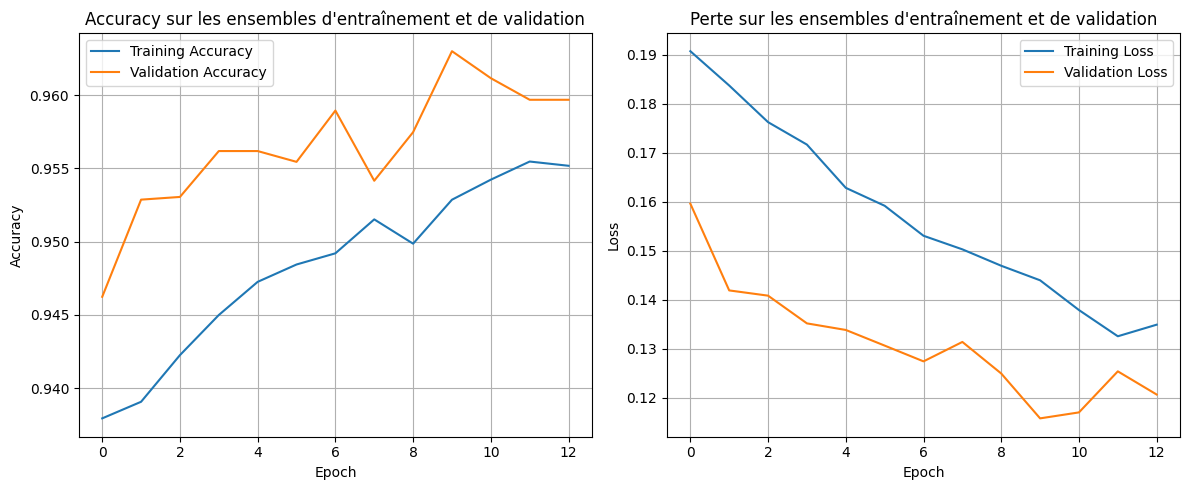

In [ ]:
print("\n--- Évaluation du modèle CNN (Transfer Learning) sur l'ensemble de test ---")

# Évaluation sur l'ensemble de test
loss_cnn, accuracy_cnn = model_cnn.evaluate(test_generator)

print(f"\nPrécision sur l'ensemble de test pour le CNN: {accuracy_cnn:.4f}\n")
print(f"Perte sur l'ensemble de test pour le CNN: {loss_cnn:.4f}\n")

# Affichage des métriques et courbes d'apprentissage
plt.figure(figsize=(12, 5))

# Courbe de Précision
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy sur les ensembles d\'entraînement et de validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Courbe de Perte
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Perte sur les ensembles d\'entraînement et de validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Matrice de Confusion pour le modèle CNN ---
340/340 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step

Rapport de classification CNN sur l'ensemble de test :
|                                                    | precision   | recall   | f1-score   | support   |
|:---------------------------------------------------|:------------|:---------|:-----------|:----------|
| Apple___Apple_scab                                 | 0.991379    | 0.912698 | 0.950413   | 126       |
| Apple___Black_rot                                  | 1           | 1        | 1          | 124       |
| Apple___Cedar_apple_rust                           | 0.995708    | 1        | 0.997849   | 232       |
| Apple___healthy                                    | 0.991189    | 0.95339  | 0.971922   | 236       |
| Blueberry___healthy                                | 0.958333    | 0.99639  | 0.976991   | 277       |
| Cherry_(including_sour)___Powdery_mildew           | 0.995349    | 0.995349 | 0.995349   | 215       |
| Cherry_(in

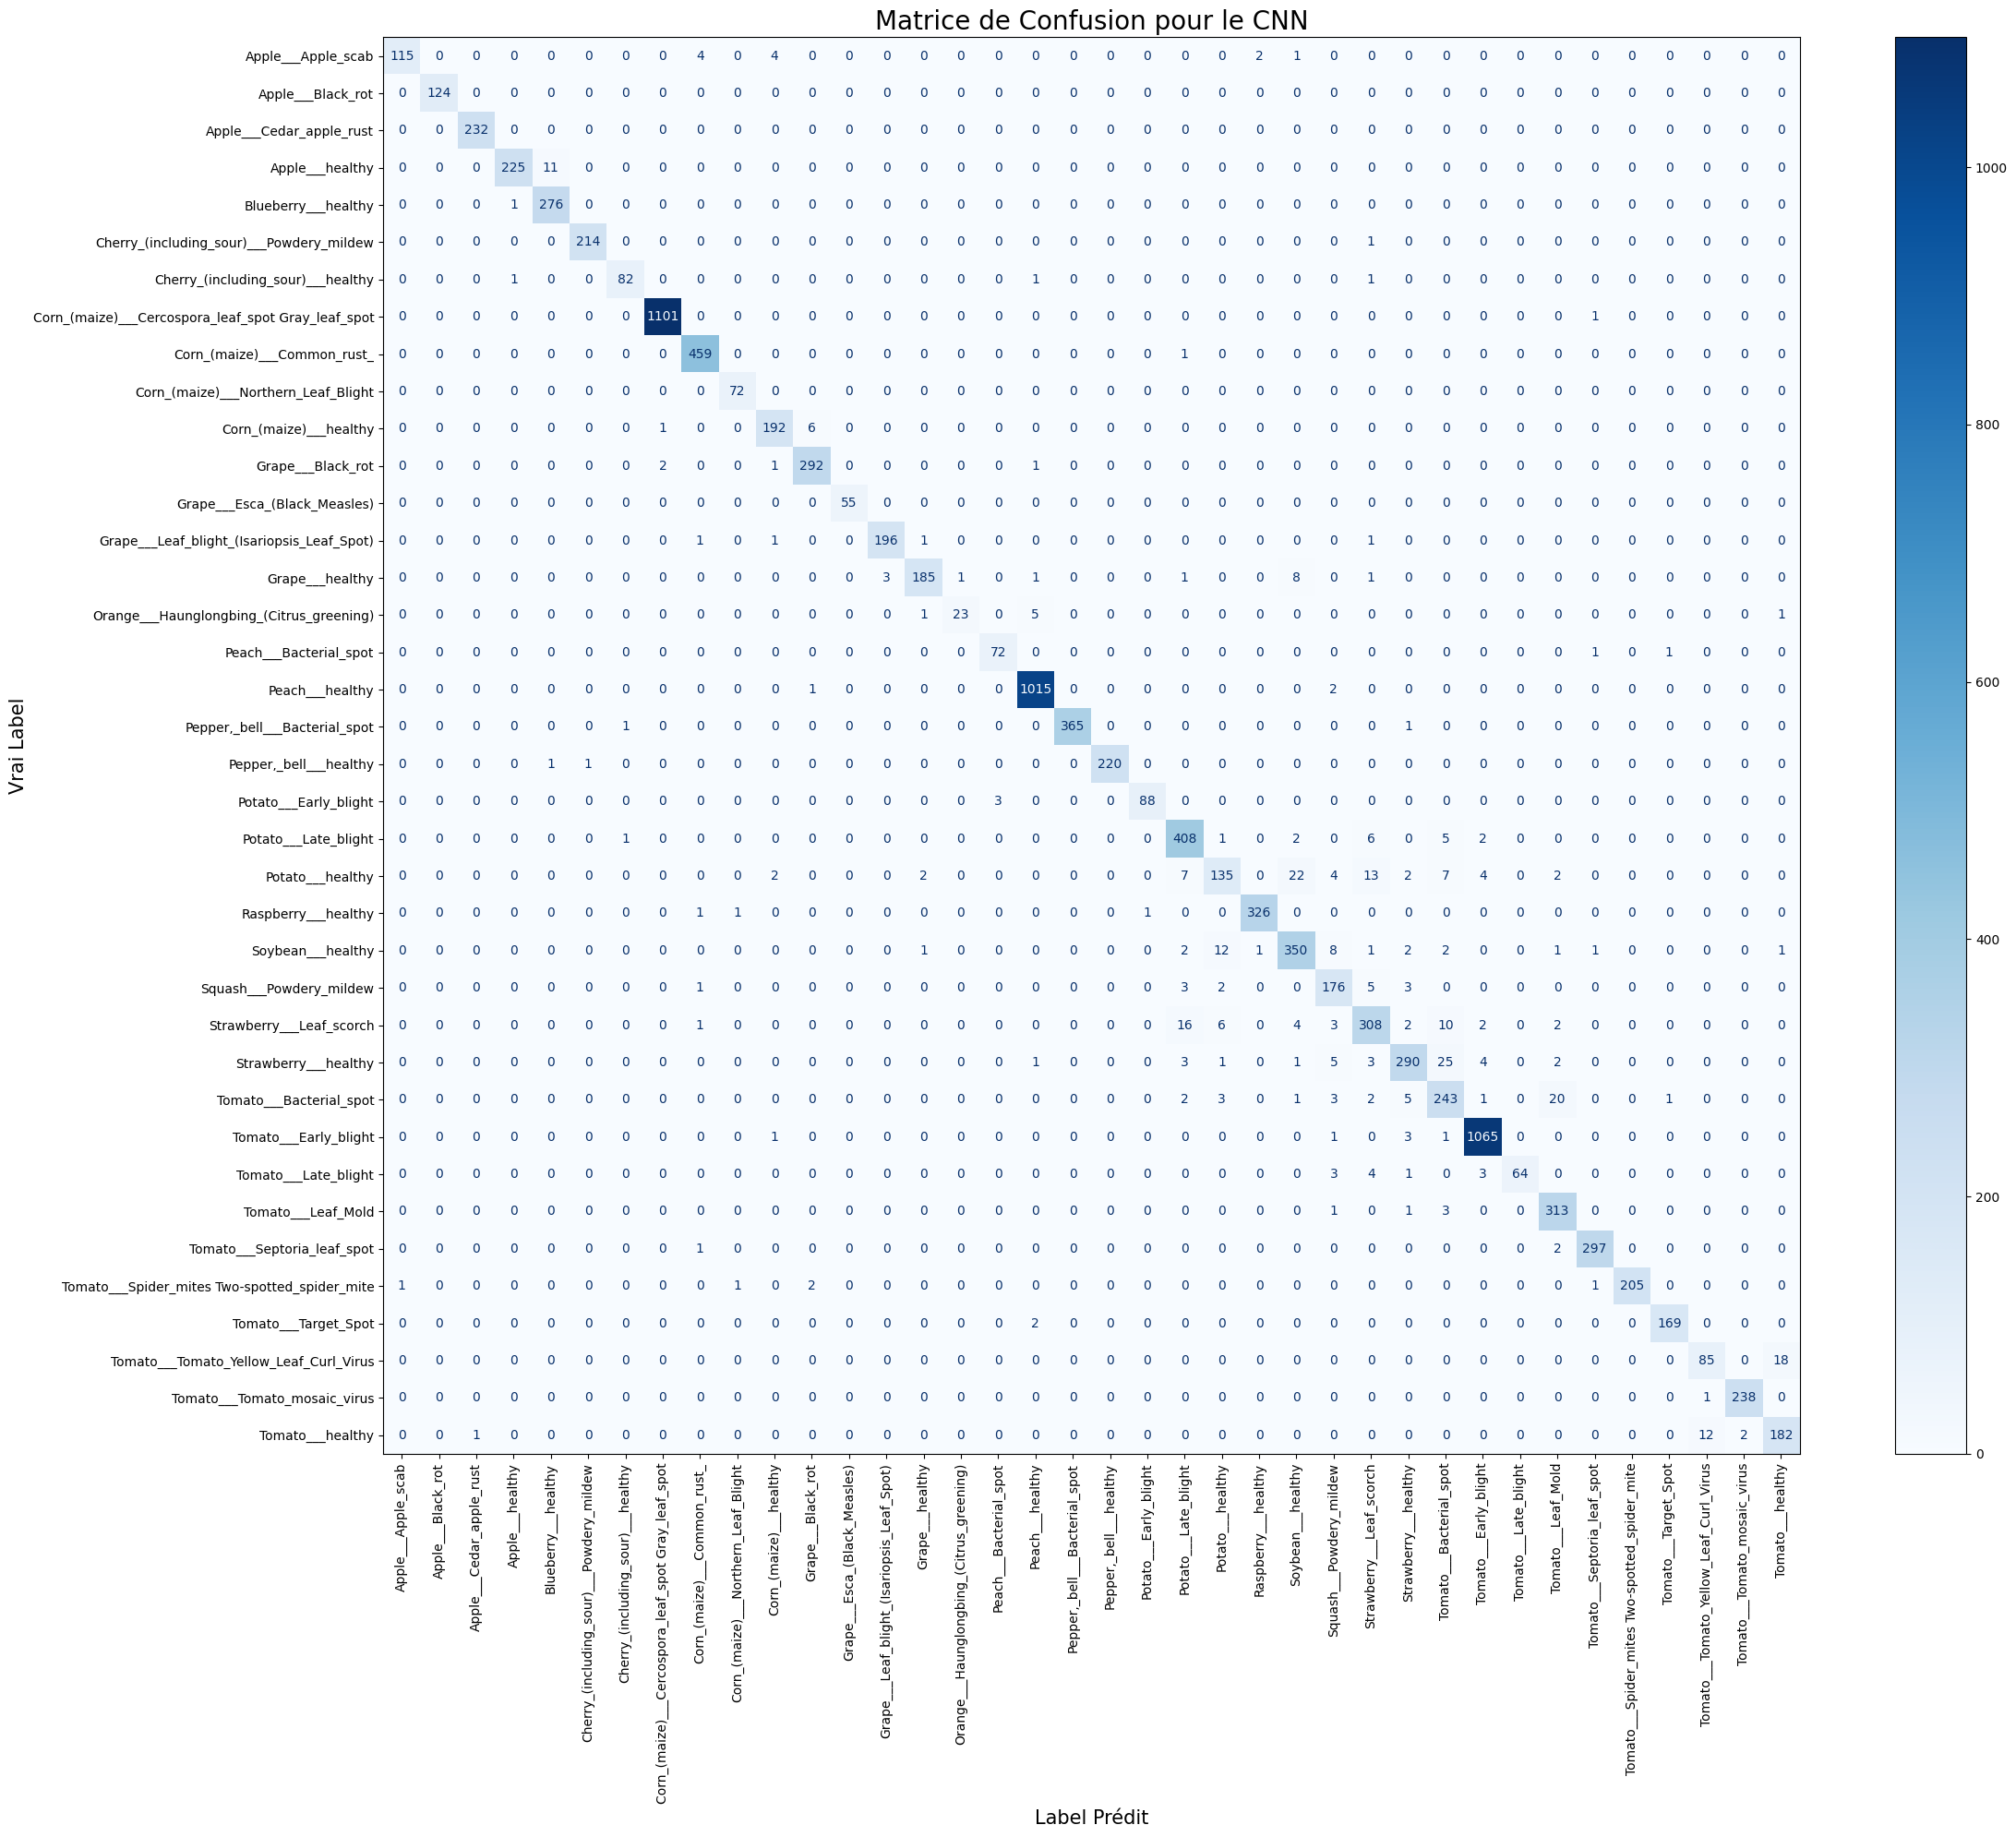

In [ ]:
print("\n--- Matrice de Confusion pour le modèle CNN ---")

# Obtenir les prédictions sur l'ensemble de test
y_pred_cnn_probs = model_cnn.predict(test_generator)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# Obtenir les vraies étiquettes de l'ensemble de test
y_true_cnn = test_generator.classes

# Générer le rapport de classification et l'afficher sous forme de tableau
print("\nRapport de classification CNN sur l'ensemble de test :")
report_cnn = classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, zero_division=0, output_dict=True)
df_report_cnn = pd.DataFrame(report_cnn).transpose()
print(df_report_cnn.to_markdown(numalign="left", stralign="left")) # Utilise to_markdown pour un affichage propre dans Colab

# Calculer la matrice de confusion
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

# Afficher la matrice de confusion avec une taille de figure plus grande et des contrôles d'axes explicites
fig, ax = plt.subplots(figsize=(25, 20)) # Créer une figure et un ensemble d'axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d', ax=ax) # Passer l'axe explicitement

ax.set_title('Matrice de Confusion pour le CNN', fontsize=20) # Définir le titre sur l'axe
ax.set_xlabel('Label Prédit', fontsize=15) # Définir l'étiquette de l'axe X sur l'axe
ax.set_ylabel('Vrai Label', fontsize=15) # Définir l'étiquette de l'axe Y sur l'axe
ax.tick_params(axis='x', labelsize=10) # Ajuster la taille de la police des labels des ticks X
ax.tick_params(axis='y', labelsize=10) # Ajuster la taille de la police des labels des ticks Y

plt.tight_layout() # Assure que les étiquettes ne se chevauchent pas
plt.show()

**Sauvegarde**

In [ ]:
print("\n--- Sauvegarde du modèle CNN entraîné ---")

# Définir le nom du fichier pour le modèle sauvegardé
model_save_path = 'best_cnn_model.keras'

# Sauvegarder le modèle au format natif Keras
model_cnn.save(model_save_path)

print(f"Modèle CNN sauvegardé avec succès sous : {model_save_path}")

# Le téléchargement du modèle sur votre machine locale a été désactivé à votre demande.
# Vous pouvez le télécharger manuellement depuis l'interface Colab si nécessaire.


--- Sauvegarde du modèle CNN entraîné ---
Modèle CNN sauvegardé avec succès sous : best_cnn_model.keras
